# Splice site usage

Summarize splice site usage (SSE, Dent et al. 2021) for developmental mamalian organs dataset (Cardoso-Moreira et al. 2019; Mazin et al. 2021).

## Setup

In [6]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import matplotlib.lines as mlines

In [7]:
TISSUE_COLORS = {
    'Brain': '#3399cc',
    'Midbrain': '#34b3e6',
    'Cerebellum': '#34ccff',
    'Heart': '#cc0100',
    'Kidney': '#cc9900',
    'Liver': '#339900',
    'Ovary': '#cc329a',
    'Testis': '#ff6600'
}

SPECIES_ORDER = ['human', 'mouse', 'rat', 'rabbit', 'opossum', 'chicken'] # 'macaque'
TISSUE_ORDER = ["Brain", "Midbrain", "Cerebellum", "Heart", "Kidney", "Liver", "Ovary", "Testis"]

In [42]:
def plot_splice_site_dynamics(
    df_all,
    site_coords,
    data_config,
    metric='SSE',
    species_order=None,
    tissue_order=None,
    tissue_colors=None,
    figsize=None,
    title=None,
    jitter=0.0
):
    """
    Plot splice site dynamics with all tissues on one plot per site.
    
    Args:
        df_all: DataFrame with all splice site data (Species, Chromosome, Position, Strand, condition columns, Alpha, Beta, SSE)
        site_coords: List of site coordinate strings (e.g., ["mouse 1:15188", "human 2:12345"]) or single string
        data_config: Config dict with condition_labels mapping for each species
        metric: Column name to plot (default: 'SSE')
        species_order: List of species in desired order (not used in single plot mode)
        tissue_order: List of tissues in desired order
        tissue_colors: Dict mapping tissue names to colors
        figsize: Tuple of (width, height) or None for auto
        title: Overall figure title
        jitter: Amount of horizontal jitter to apply to points (default: 0.0, typical: 0.1-0.3)
        
    Returns:
        matplotlib Figure object
    """
    # Convert single string to list
    if isinstance(site_coords, str):
        site_coords = [site_coords]
    
    # Parse site coordinates and filter df_all
    site_filters = []
    for coord in site_coords:
        parts = coord.strip().split()
        if len(parts) != 2:
            print(f"Warning: Invalid coordinate format '{coord}'. Expected 'species chrom:pos'")
            continue
        species = parts[0].lower()
        chrom_pos = parts[1].split(':')
        if len(chrom_pos) != 2:
            print(f"Warning: Invalid chrom:pos format in '{coord}'")
            continue
        chrom = chrom_pos[0]
        try:
            pos = int(chrom_pos[1])
        except ValueError:
            print(f"Warning: Invalid position in '{coord}'")
            continue
        site_filters.append((species, chrom, pos))
    
    if not site_filters:
        print("No valid site coordinates provided")
        return None
    
    # Set defaults
    if tissue_order is None:
        tissue_order = TISSUE_ORDER
    if tissue_colors is None:
        tissue_colors = TISSUE_COLORS
    
    # Create subplots: one per site
    n_sites = len(site_filters)
    n_cols = min(3, n_sites)  # Max 3 columns
    n_rows = (n_sites + n_cols - 1) // n_cols  # Ceiling division
    
    # Auto-calculate figure size if not provided
    if figsize is None:
        figsize = (n_cols * 6, n_rows * 4)
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize, squeeze=False)
    axes = axes.flatten()
    
    # Process each site
    for site_idx, (species, chrom, pos) in enumerate(site_filters):
        ax = axes[site_idx]
        
        # Filter df_all to this site
        mask = (df_all['Species'] == species) & (df_all['Chromosome'] == str(chrom)) & (df_all['Position'] == pos)
        df_site = df_all[mask].copy()
        
        if df_site.empty:
            ax.text(0.5, 0.5, f'No data\n{species} {chrom}:{pos}', 
                   ha='center', va='center', transform=ax.transAxes)
            ax.set_xlim(0, 1)
            ax.set_ylim(0, 1)
            continue
        
        # Find condition column name
        cond_col = next((c for c in df_site.columns if "condition" in c.lower()), None)
        if cond_col is None:
            print(f"No condition column found for {species} {chrom}:{pos}")
            continue
        
        # Map condition indices to tissue and timepoint
        tissue_list = []
        timepoint_list = []
        for idx, row in df_site.iterrows():
            sps = row['Species']
            cond_idx = row[cond_col]
            cond_labels = data_config.get(sps, {}).get('condition_labels', {})
            idx_to_name = {v: k for k, v in cond_labels.items()}
            cond_name = idx_to_name.get(int(cond_idx), None)
            
            if cond_name:
                tissue = cond_name.rsplit('_', 1)[0] if '_' in cond_name else cond_name
                try:
                    tp = int(cond_name.rsplit('_', 1)[1])
                except (IndexError, ValueError):
                    tp = None
                tissue_list.append(tissue)
                timepoint_list.append(tp)
            else:
                tissue_list.append(None)
                timepoint_list.append(None)
        
        df_site['tissue'] = tissue_list
        df_site['timepoint'] = timepoint_list
        df_site = df_site.dropna(subset=['tissue', 'timepoint'])
        df_site['timepoint'] = df_site['timepoint'].astype(int)
        
        # Get tissues present in this site
        tissues = [t for t in tissue_order if t in df_site['tissue'].values]
        
        # Get all timepoints for this site
        all_tps = sorted(df_site['timepoint'].unique())
        
        # Calculate jitter offsets for each tissue (consistent across timepoints)
        n_tissues = len(tissues)
        if jitter > 0 and n_tissues > 1:
            # Spread tissues evenly within jitter range
            tissue_offsets = {tissue: jitter * (i - (n_tissues - 1) / 2) / (n_tissues - 1) 
                            for i, tissue in enumerate(tissues)}
        else:
            tissue_offsets = {tissue: 0.0 for tissue in tissues}
        
        # Plot each tissue as a line with error bars
        for tissue in tissues:
            tissue_data = df_site[df_site['tissue'] == tissue]
            
            # Group by timepoint and calculate mean and std
            grouped = tissue_data.groupby('timepoint')[metric].agg(['mean', 'std', 'count']).reset_index()
            
            color = tissue_colors.get(tissue, '#808080')
            
            # Apply jitter offset to x-coordinates
            x_coords = grouped['timepoint'] + tissue_offsets[tissue]
            
            # Plot mean with error bars
            ax.errorbar(
                x_coords, 
                grouped['mean'],
                yerr=grouped['std'],
                fmt='o',
                color=color,
                linewidth=2,
                markersize=6,
                capsize=3,
                capthick=1.5,
                elinewidth=1.5,
                alpha=0.8,
                label=tissue
            )
            
            # Connect points with line
            ax.plot(x_coords, grouped['mean'], 
                   color=color, linewidth=1.5, alpha=0.6, zorder=1)
        
        # Formatting
        ax.grid(axis='y', alpha=0.3, linestyle='--')
        if len(all_tps) > 0:
            ax.set_xlim(all_tps[0] - 0.5, all_tps[-1] + 0.5)
        
        # Set y-axis limits for SSE
        if metric == 'SSE':
            ax.set_ylim(-0.05, 1.05)
        
        # Labels
        ax.set_xlabel('Timepoint', fontsize=10)
        ax.set_ylabel(metric, fontsize=10)
        ax.set_title(f'{species} {chrom}:{pos}', fontsize=11, fontweight='bold')
        
        # Add legend
        if tissues:
            ax.legend(loc='best', fontsize=8, framealpha=0.9)
    
    # Hide unused subplots
    for idx in range(n_sites, len(axes)):
        axes[idx].set_visible(False)
    
    # Overall title
    if title is None:
        if n_sites == 1:
            title = f'{metric} dynamics across tissues'
        else:
            title = f'{metric} dynamics for {n_sites} splice sites'
    fig.suptitle(title, fontsize=14, y=0.995)
    
    plt.tight_layout()
    return fig


## Load data

Load config file with paths to usage parquet files and metadata.

In [3]:
data_json_fn = "/home/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/data/data_config.json"
with open(data_json_fn, 'r') as f:
    data_config = json.load(f)

Load usage parquet files for all species.

In [8]:
species_list = list(data_config.keys())
species_list = [sps for sps in SPECIES_ORDER if sps in species_list]

usage_dfs = {}
for sps in species_list:
    parquet_path = os.path.expanduser(data_config[sps]["usage_parquet"])
    if not os.path.exists(parquet_path):
        print(f"Not found: {parquet_path}")
        continue
    df = pd.read_parquet(parquet_path)
    usage_dfs[sps] = df
    print(f"{sps}: {len(df):,} rows, columns: {list(df.columns)}")


human: 20,061,630 rows, columns: ['Chromosome', 'Position', 'SSE', 'Alpha', 'Beta', 'Label', 'Condition']
mouse: 20,298,041 rows, columns: ['Chromosome', 'Position', 'SSE', 'Alpha', 'Beta', 'Label', 'Condition']
rat: 24,143,168 rows, columns: ['Chromosome', 'Position', 'SSE', 'Alpha', 'Beta', 'Label', 'Condition']
rabbit: 14,038,029 rows, columns: ['Chromosome', 'Position', 'SSE', 'Alpha', 'Beta', 'Label', 'Condition']
opossum: 12,367,511 rows, columns: ['Chromosome', 'Position', 'SSE', 'Alpha', 'Beta', 'Label', 'Condition']
chicken: 7,785,924 rows, columns: ['Chromosome', 'Position', 'SSE', 'Alpha', 'Beta', 'Label', 'Condition']


In [9]:
usage_dfs['human']

,Chromosome,Position,SSE,Alpha,Beta,Label,Condition
0,1,14828,0.903,112,12,3,0
1,1,14828,0.763,71,22,3,0
2,1,14969,0.887,110,14,2,0
3,1,14969,0.531,69,61,2,0
4,1,15037,0.790,79,21,3,0
...,...,...,...,...,...,...,...
20061625,KI270711.1,29278,0.904,189,20,2,87
20061626,KI270711.1,29487,0.876,99,14,3,87
20061627,KI270711.1,29487,0.891,180,22,3,87
20061628,KI270711.1,29590,0.899,98,11,2,87


Map condition indices to names.

In [10]:
# Build a tidy DataFrame: species × condition → n_sites
# Condition labels come from data_config; usage parquet has one row per site×condition
# A site is uniquely defined by (Chromosome, Position, Strand)
records = []
for sps, df in usage_dfs.items():
    cond_labels = data_config[sps]["condition_labels"]  # name → index
    idx_to_name = {v: k for k, v in cond_labels.items()}
    known_indices = set(idx_to_name.keys())

    # Identify the condition column (may be named 'condition', 'condition_idx', etc.)
    cond_col = next((c for c in df.columns if "cond" in c.lower()), None)
    if cond_col is None:
        print(f"{sps}: no condition column found in {list(df.columns)}")
        continue

    # Extract strand from Label
    # Label mapping: 0=Donor+, 1=Acceptor+, 2=Donor-, 3=Acceptor-, 4=None
    # Strand: 0,1 → '+', 2,3 → '-', 4 → None (we'll include it as a separate category)
    df = df.copy()
    df['Strand'] = df['Label'].map({
        0: '+', 1: '+', 2: '-', 3: '-', 4: 'None'
    })

    # Count unique (Chromosome, Position, Strand) per condition
    # First filter to known condition indices
    df_filtered = df[df[cond_col].isin(known_indices)]
    
    # Group by condition and count unique sites
    for cond_idx in df_filtered[cond_col].unique():
        cond_df = df_filtered[df_filtered[cond_col] == cond_idx]
        # Count unique (Chromosome, Position, Strand) combinations
        n_unique_sites = cond_df.groupby(['Chromosome', 'Position', 'Strand']).size().shape[0]
        
        cond_name = idx_to_name[int(cond_idx)]
        tissue = cond_name.rsplit("_", 1)[0] if "_" in cond_name else cond_name
        try:
            timepoint = int(cond_name.rsplit("_", 1)[1])
        except (IndexError, ValueError):
            timepoint = None
        records.append({
            "species": sps,
            "condition_idx": int(cond_idx),
            "condition_name": cond_name,
            "tissue": tissue,
            "timepoint": timepoint,
            "n_sites": n_unique_sites,
        })

df_sites = pd.DataFrame(records)
print(f"Total rows: {len(df_sites)}")

Total rows: 481


Total number of conditions profiled per species:

Human - 92  
Mouse - 94  
Rat - 90  
Rabbit - 92  
Opossum - 82  
Chicken - 42  
Macaque - 35  

In [11]:
# Number of conditions per species
cond_counts = df_sites.groupby("species")["condition_idx"].nunique().reset_index(name="n_conditions")
# Order by SPECIES_ORDER
cond_counts["species"] = pd.Categorical(cond_counts["species"], categories=SPECIES_ORDER, ordered=True)
cond_counts = cond_counts.sort_values("species")
print(cond_counts) 

   species  n_conditions
1    human            88
2    mouse            93
5      rat            90
4   rabbit            92
3  opossum            82
0  chicken            36


In [12]:
# Diagnose: which condition indices in the parquet are NOT in data_config?
for sps, df in usage_dfs.items():
    cond_labels = data_config[sps]["condition_labels"]  # name → index
    known_indices = set(cond_labels.values())

    cond_col = next((c for c in df.columns if "cond" in c.lower()), None)
    if cond_col is None:
        continue

    parquet_indices = set(df[cond_col].unique())
    unknown = sorted(parquet_indices - known_indices)
    print(f"{sps}: {len(parquet_indices)} unique condition indices in parquet, "
          f"{len(known_indices)} in data_config")
    if unknown:
        print(f"  {len(unknown)} unmapped indices: {unknown}")


human: 88 unique condition indices in parquet, 88 in data_config
mouse: 93 unique condition indices in parquet, 93 in data_config
rat: 90 unique condition indices in parquet, 90 in data_config
rabbit: 92 unique condition indices in parquet, 92 in data_config
opossum: 82 unique condition indices in parquet, 82 in data_config
chicken: 36 unique condition indices in parquet, 36 in data_config


## Data distribution

How many splice sites are detected in each condition (tissue x timepoint) per species?

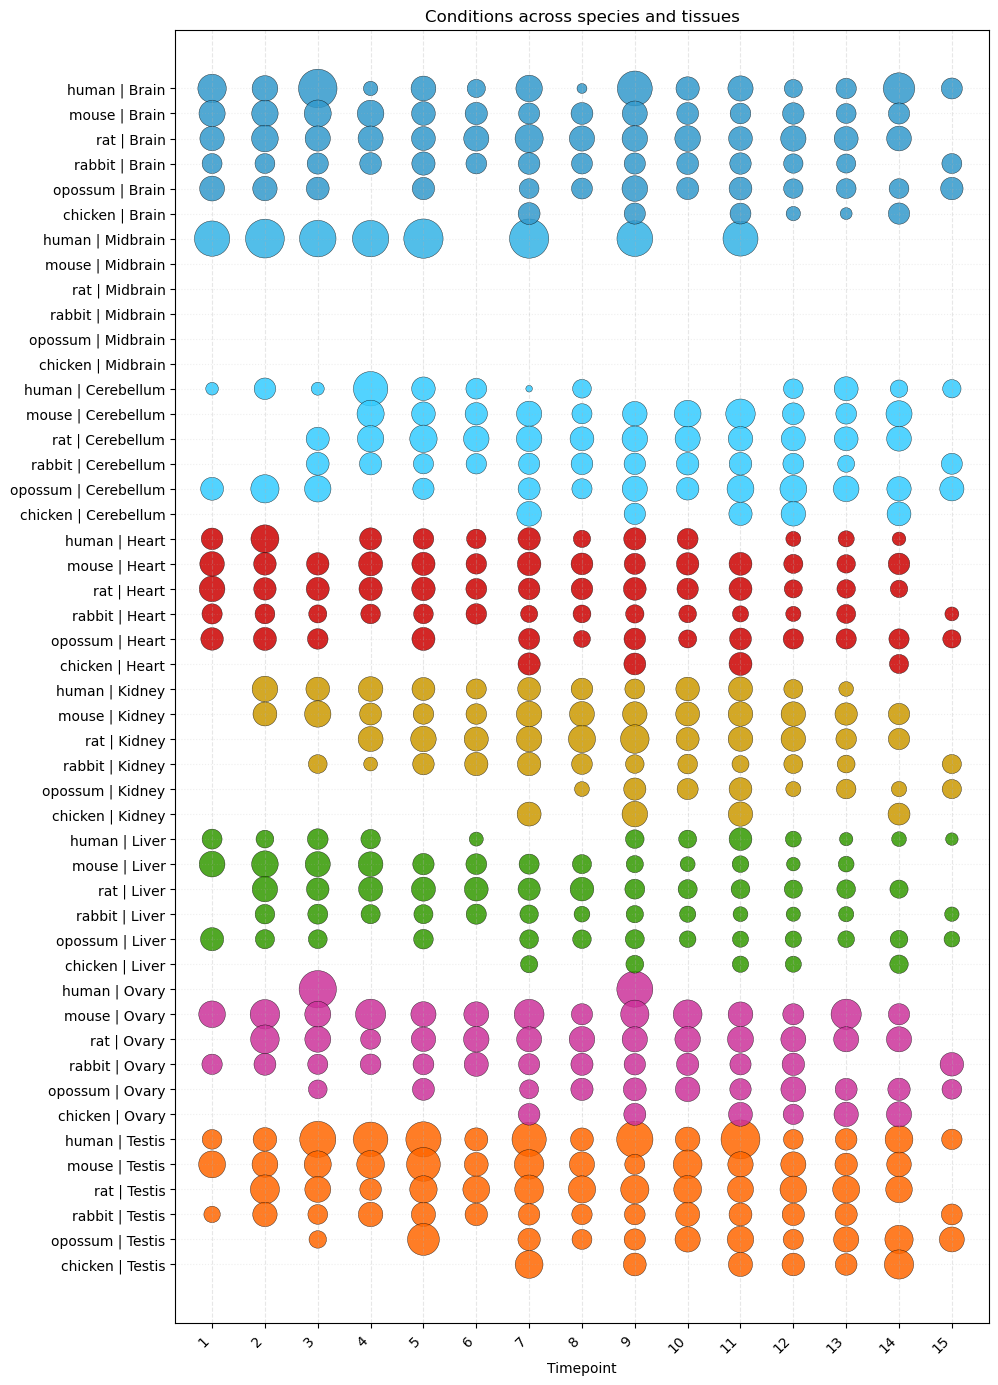

In [14]:
# Dotplot of condition overlap across species:
# y = (species | tissue), x = timepoint, dot size ∝ n_sites, dot color = tissue

species_order = [s for s in species_list[::-1] if s in set(df_sites["species"].unique())]
tissue_order = TISSUE_ORDER[::-1]
tissue_order = [t for t in tissue_order if t in set(df_sites["tissue"].unique())]

timepoints = sorted(df_sites["timepoint"].dropna().astype(int).unique())

row_labels = [f"{s} | {t}" for t in tissue_order for s in species_order]
row_to_idx = {lab: i for i, lab in enumerate(row_labels)}

plot_df = df_sites.copy()
plot_df = plot_df[plot_df["species"].isin(species_order) & plot_df["tissue"].isin(tissue_order)].copy()
plot_df["row_label"] = plot_df["species"] + " | " + plot_df["tissue"]
plot_df["row_idx"] = plot_df["row_label"].map(row_to_idx)

# Size scaling
n_max = plot_df["n_sites"].max()
min_s, max_s = 20, 800  # marker areas
plot_df["dot_size"] = min_s + (plot_df["n_sites"] / n_max) * (max_s - min_s)

# Colors by tissue
plot_df["dot_color"] = plot_df["tissue"].map(lambda t: TISSUE_COLORS.get(t, "#808080"))

fig_w = max(10, len(timepoints) * 0.7)
fig_h = max(6, len(row_labels) * 0.35)
fig, ax = plt.subplots(figsize=(fig_w, fig_h))

ax.scatter(
    plot_df["timepoint"],
    plot_df["row_idx"],
    s=plot_df["dot_size"],
    c=plot_df["dot_color"],
    alpha=0.85,
    edgecolors="black",
    linewidths=0.3,
)

ax.set_xticks(timepoints)
ax.set_xticklabels([str(tp) for tp in timepoints], rotation=45, ha="right")
ax.set_yticks(np.arange(len(row_labels)))
ax.set_yticklabels(row_labels)

ax.grid(axis="x", linestyle="--", alpha=0.3)
ax.grid(axis="y", linestyle=":", alpha=0.2)

# size legend
legend_vals = np.array([0.1, 0.35, 0.7, 1.0]) * n_max
legend_vals = np.array([50000,150000,300000,450000,600000])
legend_vals = np.around(legend_vals).astype(int)
legend_labels = [f"{v//10000}0,000" if v >= 10000 else str(v) for v in legend_vals]
legend_sizes = min_s + (legend_vals / n_max) * (max_s - min_s)
size_handles = [
    ax.scatter([], [], s=s, color="gray", alpha=0.6, edgecolors="black", linewidths=0.3, label=f"{int(v):,}")
    for s, v in zip(legend_sizes, legend_vals)
]
size_legend = ax.legend(
    handles=size_handles,
    labels=legend_labels,
    title="# sites",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    labelspacing=1.2,      # increased spacing between legend items
    handletextpad=0.8,
    borderpad=0.8
)
ax.add_artist(size_legend)

ax.set_xlabel("Timepoint")
ax.set_title("Conditions across species and tissues")
# plt.tight_layout()
plt.show()


The same as above but as barplots, for easier comparison.

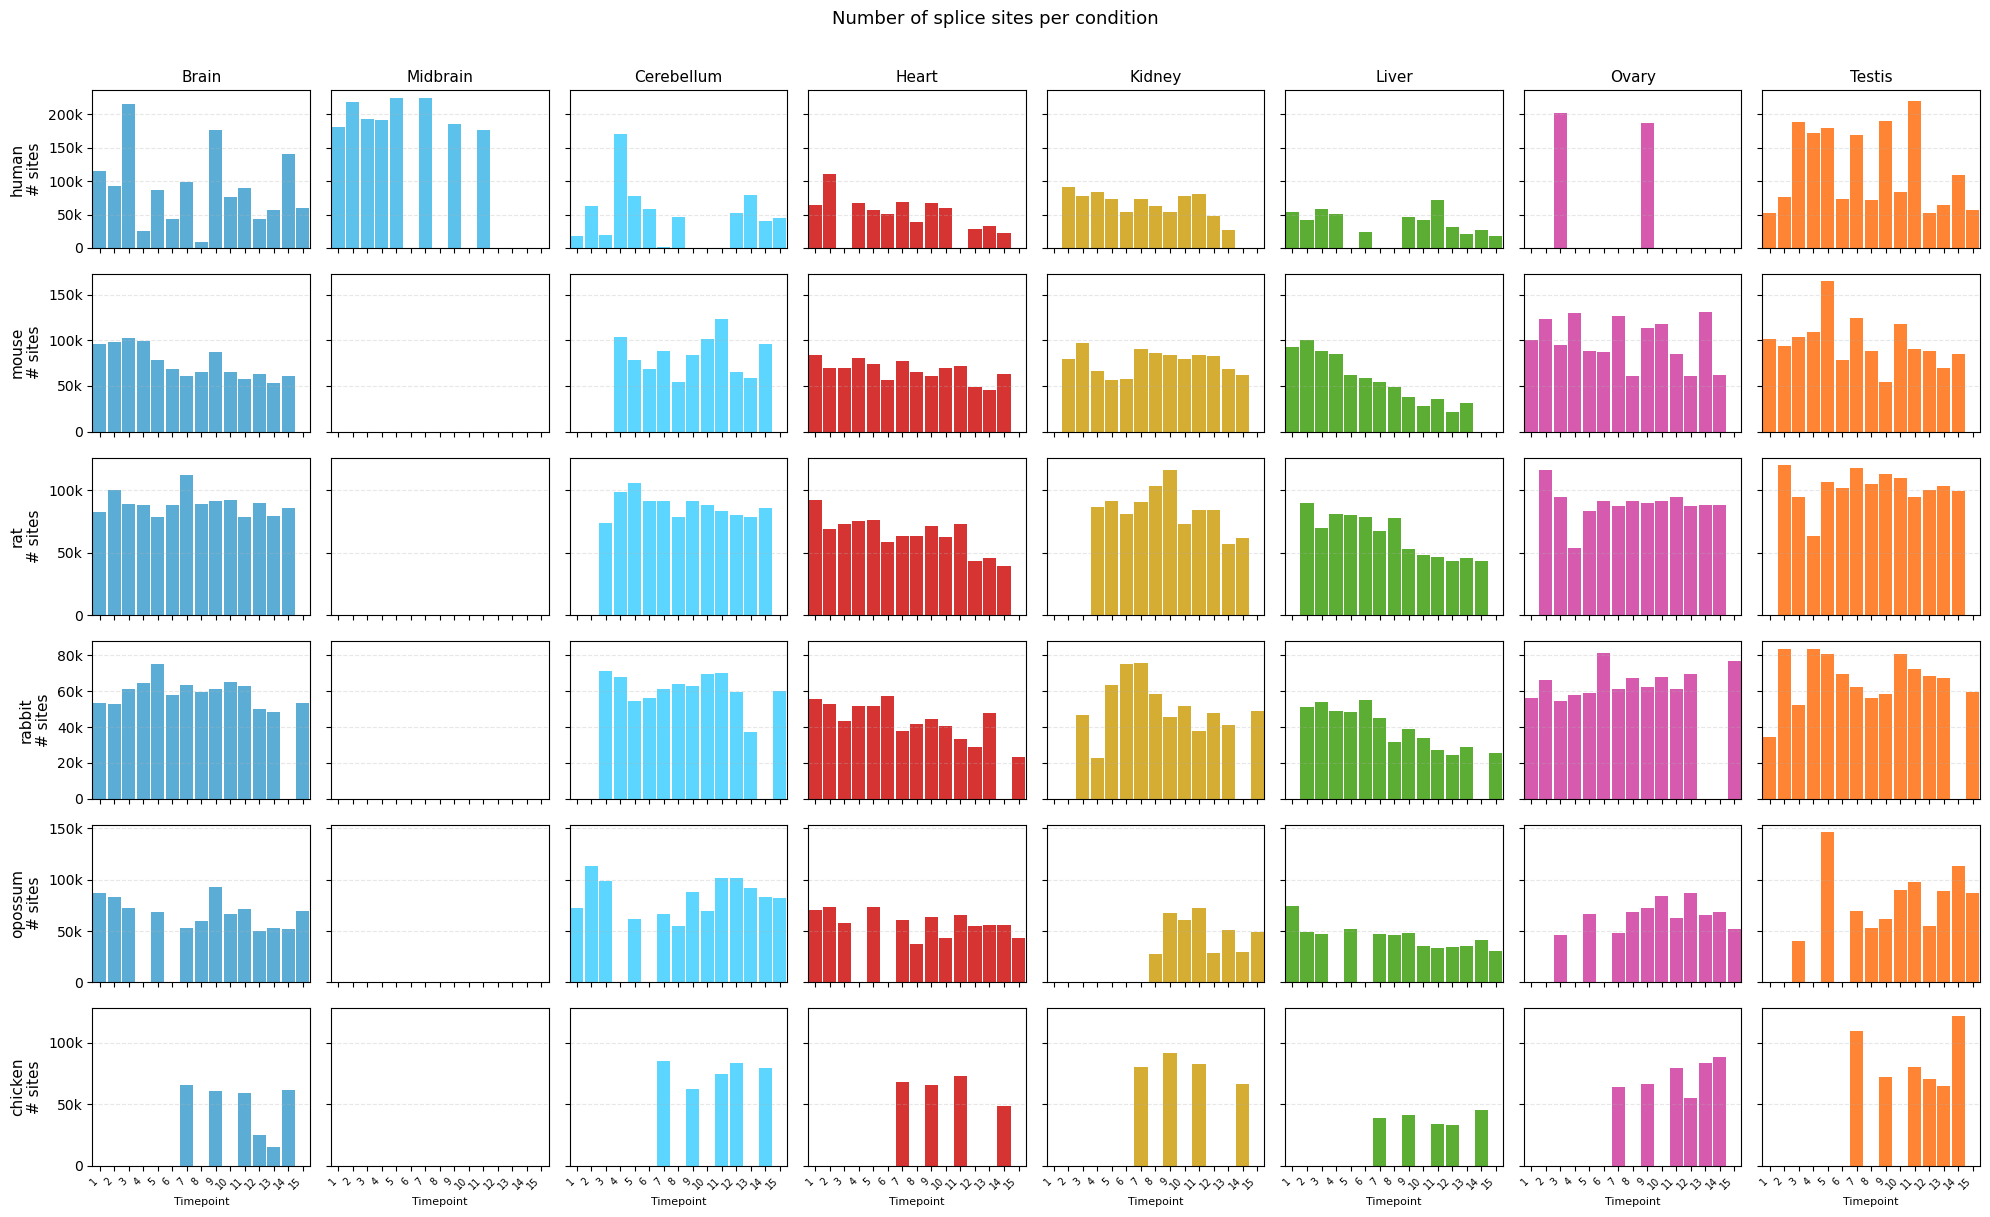

In [16]:
# Plot: n_sites per condition grouped by species, one column per tissue
# Rows = species, columns = tissues; x-axis = timepoint
# Fixed timepoints (global union across all tissues & species); unobserved → 0

present_tissues = df_sites["tissue"].unique()
tissues = [t for t in TISSUE_ORDER if t in present_tissues]
species_list_plot = [s for s in species_list if s in df_sites["species"].unique()]

# Global union of timepoints across all tissues and species
all_tps = sorted(df_sites["timepoint"].dropna().astype(int).unique())

n_tissues = len(tissues)
n_species = len(species_list_plot)

fig, axes = plt.subplots(n_species, n_tissues,
                         figsize=(n_tissues * 2.5, n_species * 2),
                         squeeze=False, sharey="row", sharex=True)

for r, sps in enumerate(species_list_plot):
    for c, tissue in enumerate(tissues):
        ax = axes[r, c]
        sub = df_sites[(df_sites["tissue"] == tissue) & (df_sites["species"] == sps)]

        tp_to_n = dict(zip(sub["timepoint"].astype("Int64"), sub["n_sites"])) if not sub.empty else {}
        heights = [tp_to_n.get(tp, 0) for tp in all_tps]

        ax.bar(range(len(all_tps)), heights, color=TISSUE_COLORS.get(tissue, "#808080"), alpha=0.8, width=0.9)
        ax.set_xlim(-0.5, len(all_tps) - 0.5)
        ax.grid(axis="y", alpha=0.3, linestyle="--")
        ax.yaxis.set_major_formatter(
            plt.FuncFormatter(lambda x, _: f"{int(x/1000)}k" if x >= 1000 else str(int(x)))
        )

        if r == 0:
            ax.set_title(tissue.capitalize(), fontsize=11)
        if c == 0:
            ax.set_ylabel(f"{sps}\n# sites", fontsize=11)
        if r == n_species - 1:
            ax.set_xticks(range(len(all_tps)))
            ax.set_xticklabels([str(tp) for tp in all_tps], rotation=45, ha="right", fontsize=7)
            ax.set_xlabel("Timepoint", fontsize=8)

fig.suptitle("Number of splice sites per condition", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


Distribution of Alpha values across conditions and species.

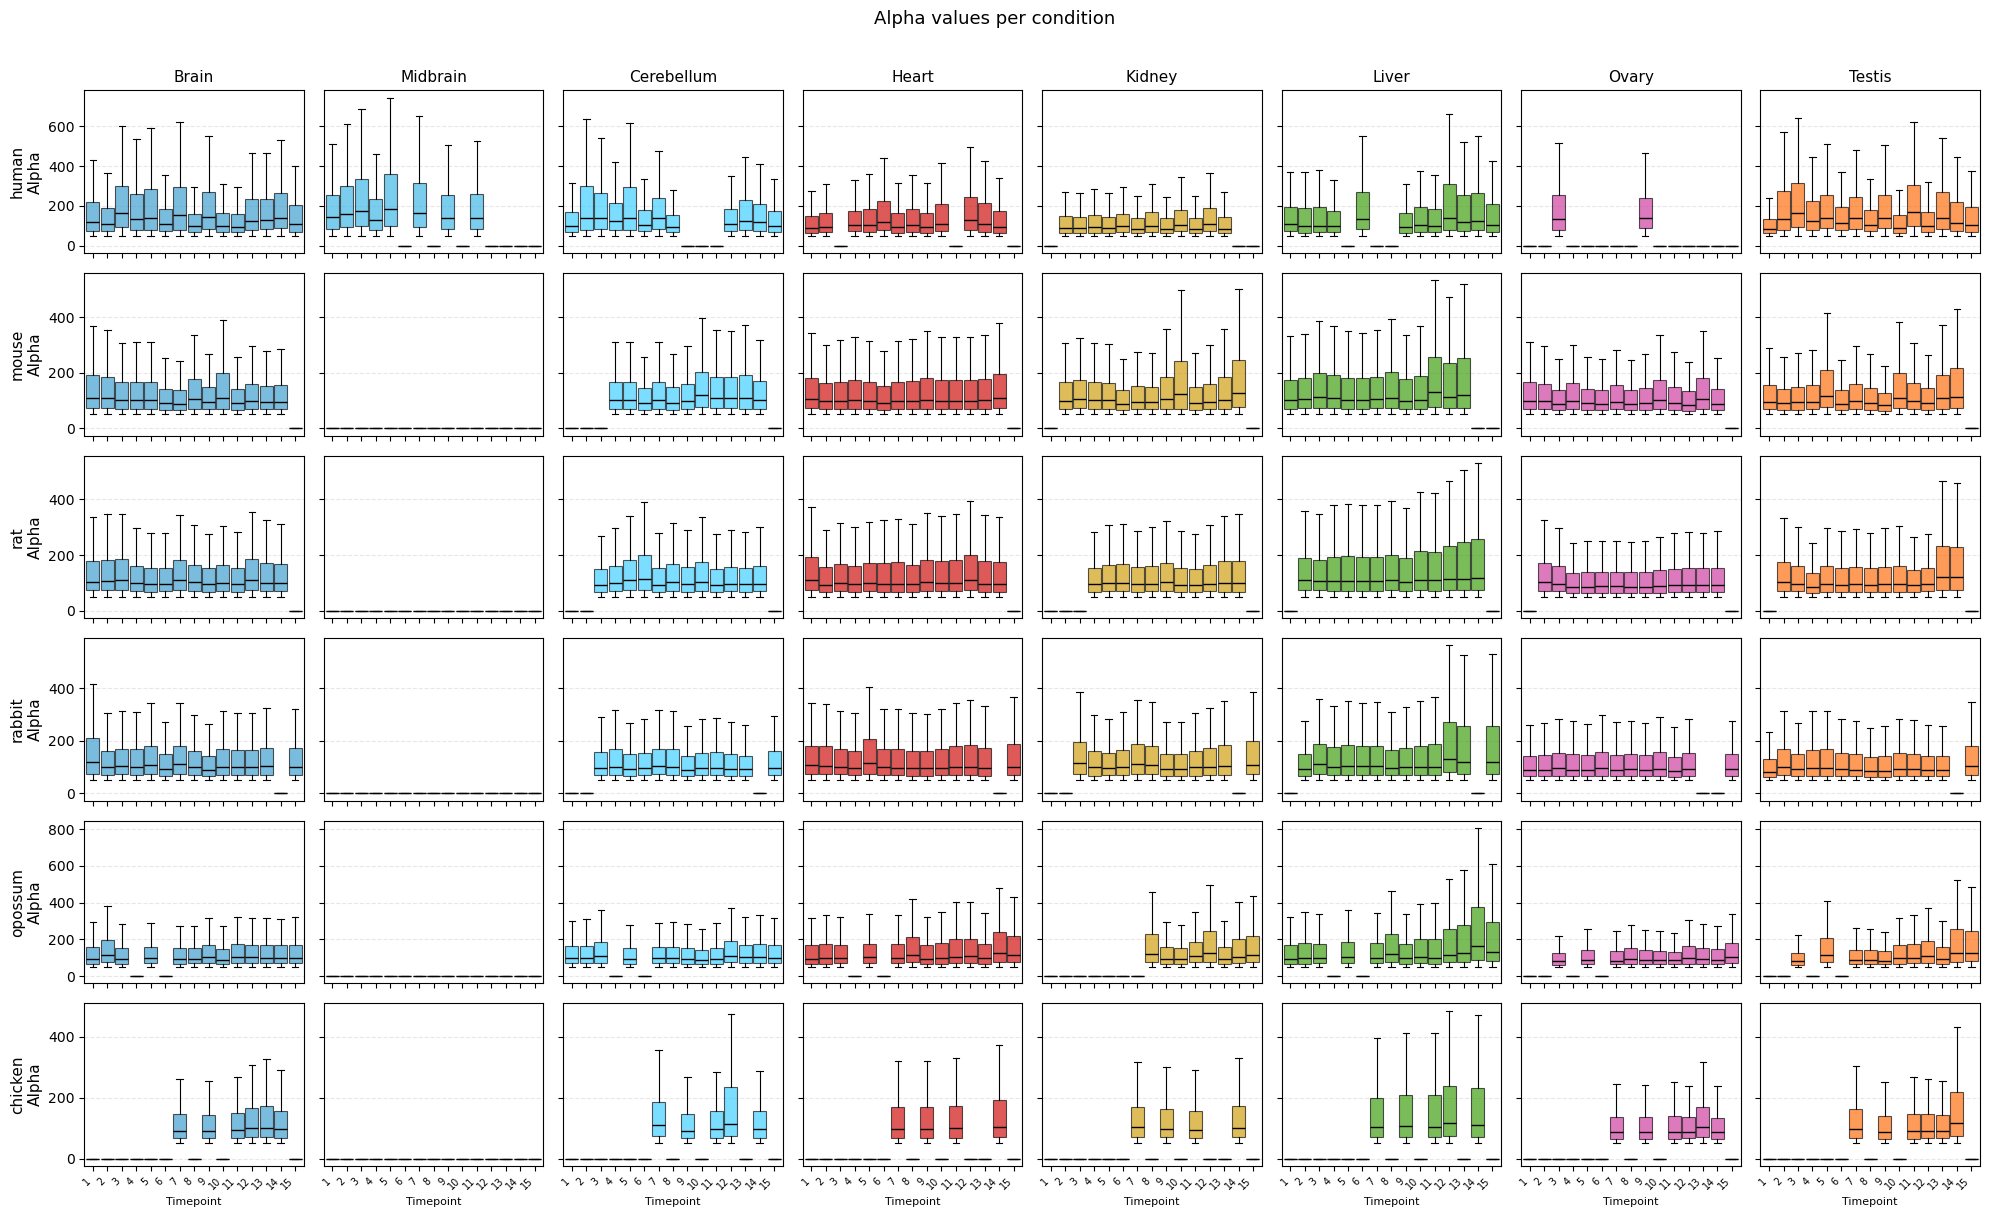

In [20]:
# Boxplot: Alpha distribution per condition grouped by species (rows) and tissues (cols)
# x-axis = fixed global timepoints (all_tps); unobserved timepoints get a dummy [0]

species_list_plot = [s for s in species_list if s in usage_dfs]
tissues = [t for t in TISSUE_ORDER if t in set(df_sites["tissue"].unique())]

# Precompute per-species Alpha arrays by (tissue, timepoint)
alpha_groups = {}
for sps in species_list_plot:
    df_sps = usage_dfs[sps]
    cond_col_sps = next((c for c in df_sps.columns if "cond" in c.lower()), None)
    if cond_col_sps is None:
        print(f"{sps}: no condition column found")
        continue

    cond_labels_sps = data_config[sps]["condition_labels"]  # name -> index
    idx_to_name_sps = {v: k for k, v in cond_labels_sps.items()}

    cond_to_tissue = {}
    cond_to_timepoint = {}
    for idx, name in idx_to_name_sps.items():
        tissue_name = name.rsplit("_", 1)[0] if "_" in name else name
        try:
            tp = int(name.rsplit("_", 1)[1])
        except (IndexError, ValueError):
            continue
        cond_to_tissue[idx] = tissue_name
        cond_to_timepoint[idx] = tp

    tmp = df_sps[[cond_col_sps, "Alpha"]].copy()
    tmp["tissue"] = tmp[cond_col_sps].map(cond_to_tissue)
    tmp["timepoint"] = tmp[cond_col_sps].map(cond_to_timepoint)
    tmp = tmp.dropna(subset=["tissue", "timepoint"])
    tmp["timepoint"] = tmp["timepoint"].astype(int)

    grouped = tmp.groupby(["tissue", "timepoint"])["Alpha"].apply(lambda x: x.to_numpy())
    alpha_groups[sps] = grouped.to_dict()

n_tissues = len(tissues)
n_species = len(species_list_plot)

fig, axes = plt.subplots(
    n_species, n_tissues,
    figsize=(n_tissues * 2.5, n_species * 2),
    squeeze=False,
    sharex=True,
    sharey="row"
)

for r, sps in enumerate(species_list_plot):
    for c, tissue in enumerate(tissues):
        ax = axes[r, c]
        grp = alpha_groups.get(sps, {})

        box_data = [grp.get((tissue, int(tp)), np.array([0])) for tp in all_tps]
        positions = np.arange(len(all_tps))

        bp = ax.boxplot(
            box_data,
            positions=positions,
            widths=0.9,
            patch_artist=True,
            showfliers=False,
            medianprops={"color": "black", "linewidth": 1.0},
            whiskerprops={"linewidth": 0.8},
            capprops={"linewidth": 0.8},
            boxprops={"linewidth": 0.8},
        )

        for patch in bp["boxes"]:
            patch.set_facecolor(TISSUE_COLORS.get(tissue, "#808080"))
            patch.set_alpha(0.65)

        ax.grid(axis="y", alpha=0.3, linestyle="--")
        ax.set_xlim(-0.6, len(all_tps) - 0.4)

        if r == 0:
            ax.set_title(tissue.capitalize(), fontsize=11)
        if c == 0:
            ax.set_ylabel(f"{sps}\nAlpha", fontsize=11)
        if r == n_species - 1:
            ax.set_xticks(positions)
            ax.set_xticklabels([str(int(tp)) for tp in all_tps], rotation=45, ha="right", fontsize=7)
            ax.set_xlabel("Timepoint", fontsize=8)

fig.suptitle("Alpha values per condition", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

Distribution of counts (Alpha + Beta) per splice site across conditions and species.

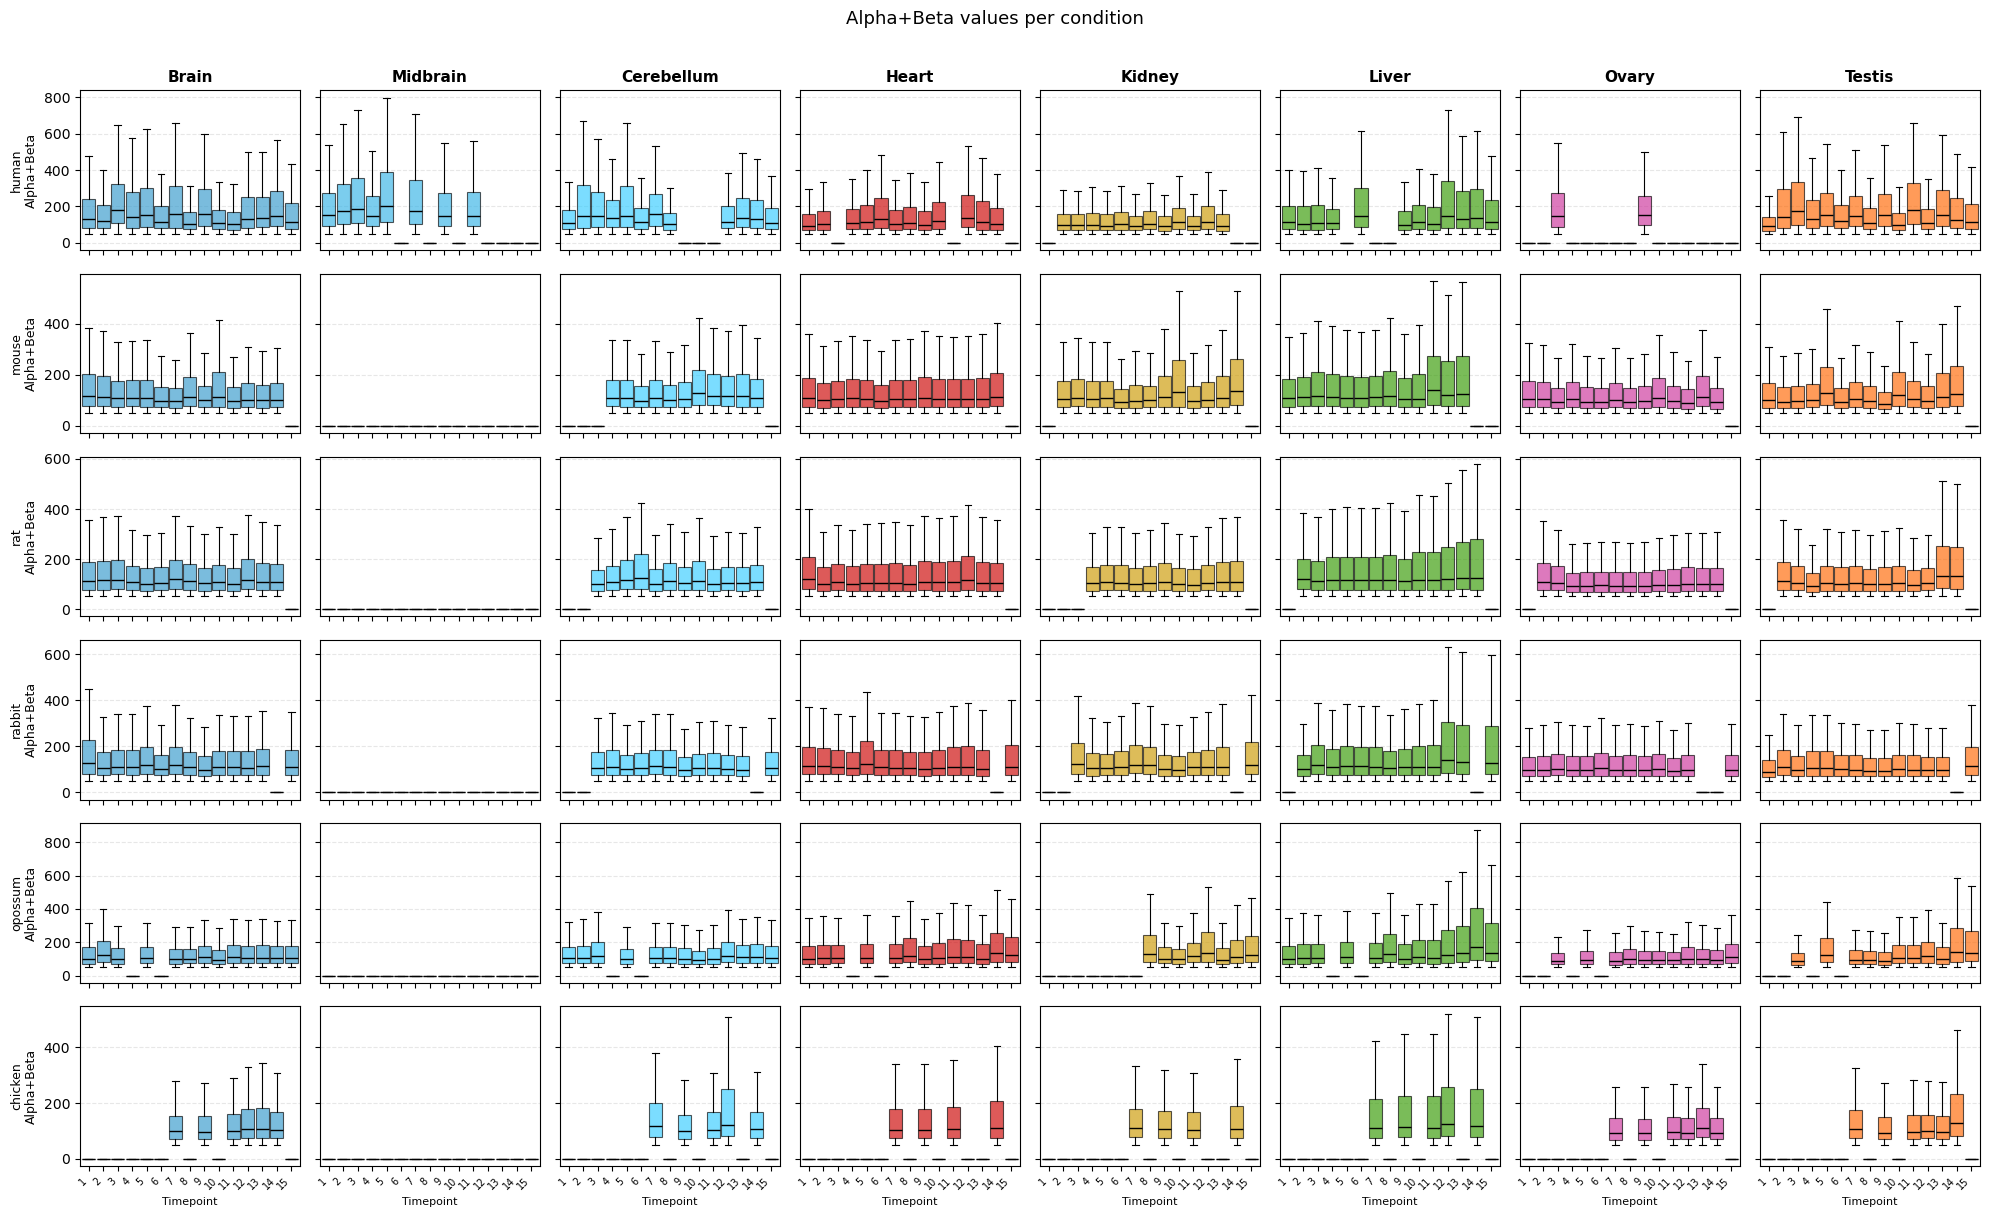

In [21]:
# Boxplot: (Alpha + Beta) distribution per condition grouped by species (rows) and tissues (cols)
# x-axis = fixed global timepoints (all_tps); unobserved timepoints get a dummy [0.0]

species_list_plot = [s for s in species_list if s in usage_dfs]
tissues = [t for t in TISSUE_ORDER if t in set(df_sites["tissue"].unique())]

# Precompute per-species (Alpha+Beta) arrays by (tissue, timepoint)
alphabeta_groups = {}
for sps in species_list_plot:
    df_sps = usage_dfs[sps]
    cond_col_sps = next((c for c in df_sps.columns if "cond" in c.lower()), None)
    if cond_col_sps is None:
        print(f"{sps}: no condition column found")
        continue

    cond_labels_sps = data_config[sps]["condition_labels"]  # name -> index
    idx_to_name_sps = {v: k for k, v in cond_labels_sps.items()}

    cond_to_tissue = {}
    cond_to_timepoint = {}
    for idx, name in idx_to_name_sps.items():
        tissue_name = name.rsplit("_", 1)[0] if "_" in name else name
        try:
            tp = int(name.rsplit("_", 1)[1])
        except (IndexError, ValueError):
            continue
        cond_to_tissue[idx] = tissue_name
        cond_to_timepoint[idx] = tp

    tmp = df_sps[[cond_col_sps, "Alpha", "Beta"]].copy()
    tmp["AlphaPlusBeta"] = tmp["Alpha"] + tmp["Beta"]
    tmp["tissue"] = tmp[cond_col_sps].map(cond_to_tissue)
    tmp["timepoint"] = tmp[cond_col_sps].map(cond_to_timepoint)
    tmp = tmp.dropna(subset=["tissue", "timepoint"])
    tmp["timepoint"] = tmp["timepoint"].astype(int)

    grouped = tmp.groupby(["tissue", "timepoint"])["AlphaPlusBeta"].apply(lambda x: x.to_numpy())
    alphabeta_groups[sps] = grouped.to_dict()

n_tissues = len(tissues)
n_species = len(species_list_plot)

fig, axes = plt.subplots(
    n_species, n_tissues,
    figsize=(n_tissues * 2.5, n_species * 2),
    squeeze=False,
    sharex=True,
    sharey="row"
)

for r, sps in enumerate(species_list_plot):
    for c, tissue in enumerate(tissues):
        ax = axes[r, c]
        grp = alphabeta_groups.get(sps, {})

        box_data = [grp.get((tissue, int(tp)), np.array([0.0])) for tp in all_tps]
        positions = np.arange(len(all_tps))

        bp = ax.boxplot(
            box_data,
            positions=positions,
            widths=0.9,
            patch_artist=True,
            showfliers=False,
            medianprops={"color": "black", "linewidth": 1.0},
            whiskerprops={"linewidth": 0.8},
            capprops={"linewidth": 0.8},
            boxprops={"linewidth": 0.8},
        )

        for patch in bp["boxes"]:
            patch.set_facecolor(TISSUE_COLORS.get(tissue, "#808080"))
            patch.set_alpha(0.65)

        ax.grid(axis="y", alpha=0.3, linestyle="--")
        ax.set_xlim(-0.6, len(all_tps) - 0.4)

        if r == 0:
            ax.set_title(tissue.capitalize(), fontsize=11, fontweight="bold")
        if c == 0:
            ax.set_ylabel(f"{sps}\nAlpha+Beta", fontsize=9)
        if r == n_species - 1:
            ax.set_xticks(positions)
            ax.set_xticklabels([str(int(tp)) for tp in all_tps], rotation=45, ha="right", fontsize=7)
            ax.set_xlabel("Timepoint", fontsize=8)

fig.suptitle("Alpha+Beta values per condition", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

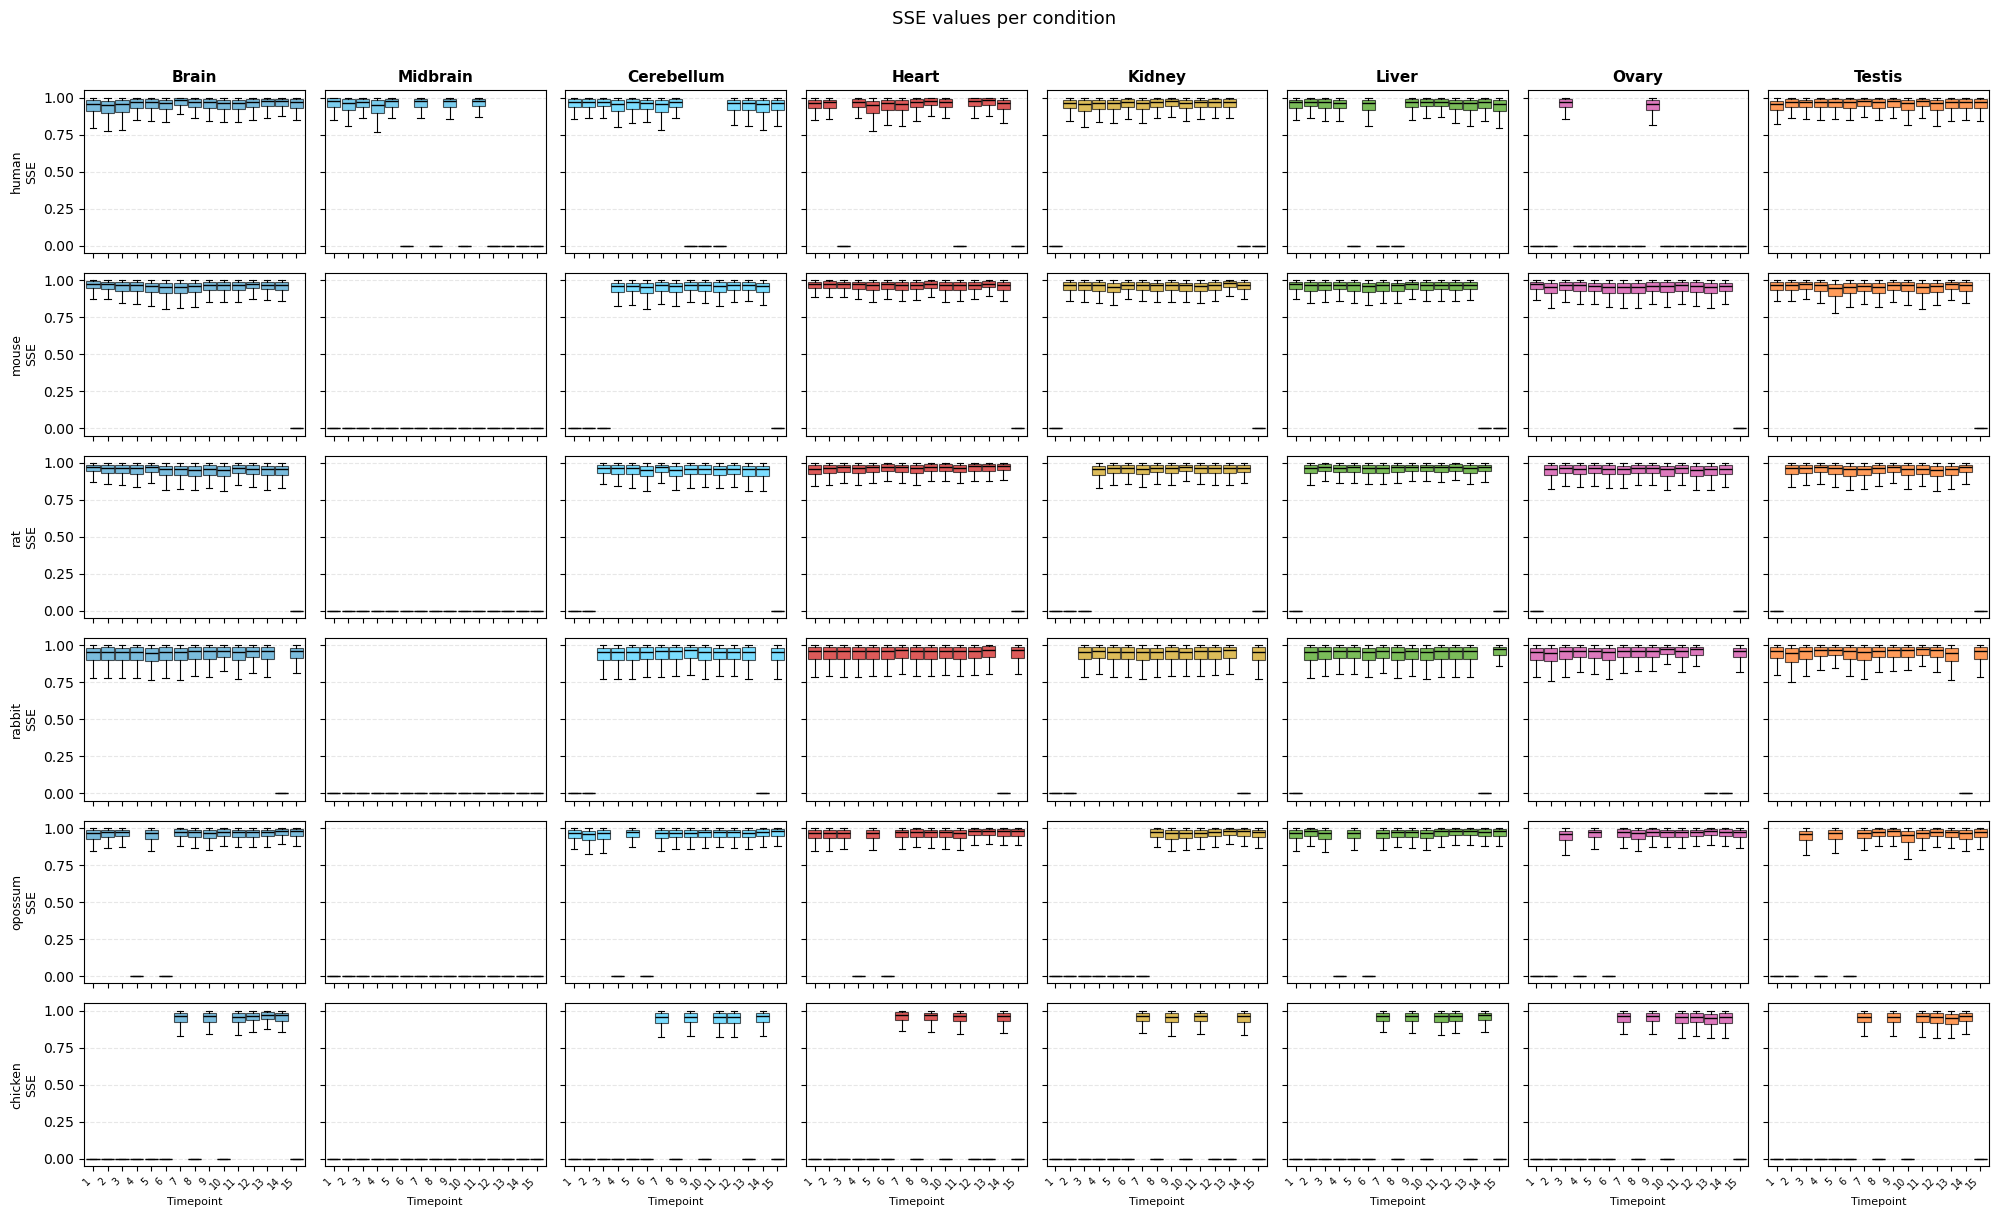

In [22]:
# Boxplot: SSE distribution per condition grouped by species (rows) and tissues (cols)
# x-axis = fixed global timepoints (all_tps); unobserved timepoints get a dummy [0]

species_list_plot = [s for s in species_list if s in usage_dfs]
tissues = [t for t in TISSUE_ORDER if t in set(df_sites["tissue"].unique())]

# Precompute per-species SSE arrays by (tissue, timepoint)
sse_groups = {}
for sps in species_list_plot:
    df_sps = usage_dfs[sps]
    cond_col_sps = next((c for c in df_sps.columns if "cond" in c.lower()), None)
    if cond_col_sps is None:
        print(f"{sps}: no condition column found")
        continue

    cond_labels_sps = data_config[sps]["condition_labels"]  # name -> index
    idx_to_name_sps = {v: k for k, v in cond_labels_sps.items()}

    cond_to_tissue = {}
    cond_to_timepoint = {}
    for idx, name in idx_to_name_sps.items():
        tissue_name = name.rsplit("_", 1)[0] if "_" in name else name
        try:
            tp = int(name.rsplit("_", 1)[1])
        except (IndexError, ValueError):
            continue
        cond_to_tissue[idx] = tissue_name
        cond_to_timepoint[idx] = tp

    tmp = df_sps[[cond_col_sps, "SSE"]].copy()
    tmp["tissue"] = tmp[cond_col_sps].map(cond_to_tissue)
    tmp["timepoint"] = tmp[cond_col_sps].map(cond_to_timepoint)
    tmp = tmp.dropna(subset=["tissue", "timepoint"])
    tmp["timepoint"] = tmp["timepoint"].astype(int)

    grouped = tmp.groupby(["tissue", "timepoint"])["SSE"].apply(lambda x: x.to_numpy())
    sse_groups[sps] = grouped.to_dict()

n_tissues = len(tissues)
n_species = len(species_list_plot)

fig, axes = plt.subplots(
    n_species, n_tissues,
    figsize=(n_tissues * 2.5, n_species * 2),
    squeeze=False,
    sharex=True,
    sharey="row"
)

for r, sps in enumerate(species_list_plot):
    for c, tissue in enumerate(tissues):
        ax = axes[r, c]
        grp = sse_groups.get(sps, {})

        box_data = [grp.get((tissue, int(tp)), np.array([0.0])) for tp in all_tps]
        positions = np.arange(len(all_tps))

        bp = ax.boxplot(
            box_data,
            positions=positions,
            widths=0.9,
            patch_artist=True,
            showfliers=False,
            medianprops={"color": "black", "linewidth": 1.0},
            whiskerprops={"linewidth": 0.8},
            capprops={"linewidth": 0.8},
            boxprops={"linewidth": 0.8},
        )

        for patch in bp["boxes"]:
            patch.set_facecolor(TISSUE_COLORS.get(tissue, "#808080"))
            patch.set_alpha(0.65)

        ax.grid(axis="y", alpha=0.3, linestyle="--")
        ax.set_xlim(-0.6, len(all_tps) - 0.4)

        if r == 0:
            ax.set_title(tissue.capitalize(), fontsize=11, fontweight="bold")
        if c == 0:
            ax.set_ylabel(f"{sps}\nSSE", fontsize=9)
        if r == n_species - 1:
            ax.set_xticks(positions)
            ax.set_xticklabels([str(int(tp)) for tp in all_tps], rotation=45, ha="right", fontsize=7)
            ax.set_xlabel("Timepoint", fontsize=8)

fig.suptitle("SSE values per condition", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## Developmental dynamics

In [29]:
# Build a tidy DataFrame with all results
records = []
for sps, df in usage_dfs.items():
    cond_labels = data_config[sps]["condition_labels"]  # name → index
    idx_to_name = {v: k for k, v in cond_labels.items()}
    known_indices = set(idx_to_name.keys())

    # Identify the condition column (may be named 'condition', 'condition_idx', etc.)
    cond_col = next((c for c in df.columns if "cond" in c.lower()), None)
    if cond_col is None:
        print(f"{sps}: no condition column found in {list(df.columns)}")
        continue

    # Extract strand from Label
    # Label mapping: 0=Donor+, 1=Acceptor+, 2=Donor-, 3=Acceptor-, 4=None
    # Strand: 0,1 → '+', 2,3 → '-', 4 → None (we'll include it as a separate category)
    df = df.copy()
    df['Strand'] = df['Label'].map({
        0: '+', 1: '+', 2: '-', 3: '-', 4: 'None'
    })
    df_filtered['Species'] = sps
    # Species as first column
    cols = ['Species'] + [c for c in df_filtered.columns if c != 'Species']
    df_filtered = df_filtered[cols] 
    
    # Append to records
    records.append(df_filtered)

# Merge all records into a single DataFrame
df_all = pd.concat(records, ignore_index=True)
print(f"Combined DataFrame: {len(df_all):,} rows, columns: {list(df_all.columns)}")

Combined DataFrame: 46,715,544 rows, columns: ['Species', 'Chromosome', 'Position', 'SSE', 'Alpha', 'Beta', 'Label', 'Condition', 'Strand']


In [37]:
# Select for plotting
df_plot = df_all[(df_all['Species'] == 'mouse') & (df_all['Chromosome'] == '1') & (df_all['Position'] == 15188)]
df_plot

,Species,Chromosome,Position,SSE,Alpha,Beta,Label,Condition,Strand
0,mouse,1,15188,0.971,68,2,0,0,+
1,mouse,1,15188,0.905,57,6,0,0,+
199354,mouse,1,15188,0.986,72,1,0,1,+
199355,mouse,1,15188,0.920,80,7,0,1,+
199356,mouse,1,15188,1.000,116,0,0,1,+
...,...,...,...,...,...,...,...,...,...
7272772,mouse,1,15188,0.955,63,3,0,33,+
7495392,mouse,1,15188,0.847,105,19,0,34,+
7495393,mouse,1,15188,0.827,182,38,0,34,+
7659663,mouse,1,15188,0.921,186,16,0,35,+


## Plot splice site dynamics

The `plot_splice_site_dynamics` function plots SSE (or other metrics) for specific splice sites across tissues and timepoints. 

**Key features:**
- Takes site coordinates as input (e.g., `"mouse 1:15188"` or list of coordinates)
- Shows mean values with error bars (standard deviation) when multiple observations exist per condition
- Creates **one plot per site** with all tissues shown as colored lines on the same axes
- Each tissue gets a distinct color from TISSUE_COLORS
- Can plot any metric: SSE, Alpha, Beta, or Alpha+Beta
- Supports multiple sites (creates subplots in a grid layout)
- Optional horizontal jitter to prevent overlapping points (use `jitter=0.15` for slight offset)

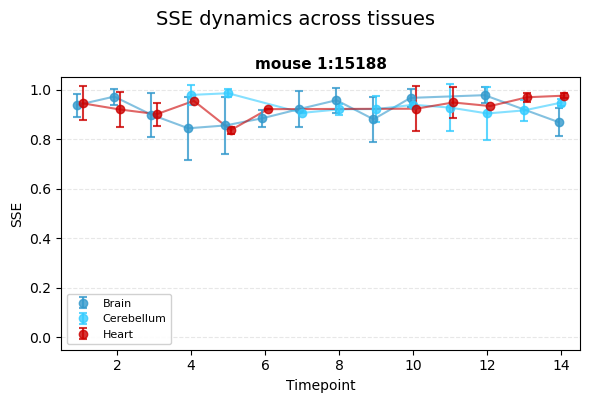

In [43]:
# Example usage: Plot SSE dynamics for a specific splice site
fig = plot_splice_site_dynamics(
    df_all,
    site_coords="mouse 1:15188",
    data_config=data_config,
    metric='SSE',
    species_order=SPECIES_ORDER,
    tissue_order=TISSUE_ORDER,
    tissue_colors=TISSUE_COLORS,
    jitter=0.15
)
plt.show()

In [ ]:
# Example: Plot multiple sites at once
# Each site gets its own subplot with all tissues on the same plot
# fig = plot_splice_site_dynamics(
#     df_all,
#     site_coords=["mouse 1:15188", "mouse 1:20000"],  # List of coordinates
#     data_config=data_config,
#     metric='SSE',
#     jitter=0.2  # Spread points horizontally to avoid overlap
# )
# plt.show()

# Example: Plot Alpha values instead of SSE
# fig = plot_splice_site_dynamics(
#     df_all,
#     site_coords="mouse 1:15188",
#     data_config=data_config,
#     metric='Alpha',
#     title='Alpha dynamics across tissues',
#     jitter=0.1
# )
# plt.show()